## import packages

In [7]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

device = torch.device("cuda:0")


import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from nn_functions import surrogate
from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss, TiDE_forward

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN


cuda is available


## define funcitons

In [8]:
# values from user
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [9]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


In [10]:
import copy
import torch

def run_one_step_policy(
    GAMMA_obj,
    policy_model,
    P,
    window,
    mc_samples=50
):
    # =========================================================
    # 1. Reference trajectory
    # =========================================================
    mp_temp_ref = GAMMA_obj.ref[
        GAMMA_obj.MPC_counter : GAMMA_obj.MPC_counter + P
    ]
    mp_temp_ref_t = torch.as_tensor(
        mp_temp_ref, dtype=torch.float32, device=device
    ).reshape(1, P, 1)

    # =========================================================
    # 2. Past inputs
    # =========================================================
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)
    laser_past_t   = GAMMA_obj.u_past.view(1, -1, 1).to(device)

    fix_cov_past = GAMMA_obj.fix_cov_all[
        GAMMA_obj.MPC_counter - window : GAMMA_obj.MPC_counter, :
    ]
    fix_cov_past_t = torch.as_tensor(
        fix_cov_past, dtype=torch.float32, device=device
    ).unsqueeze(0)

    # =========================================================
    # 3. Normalize
    # =========================================================
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s   = normalize_x(laser_past_t,   dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    policy_in_past = torch.cat(
        (fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2
    )

    # =========================================================
    # 4. Future inputs
    # =========================================================
    fix_cov_future = GAMMA_obj.fix_cov_all[
        GAMMA_obj.MPC_counter : GAMMA_obj.MPC_counter + P, :
    ]
    fix_cov_future_t = torch.as_tensor(
        fix_cov_future, dtype=torch.float32, device=device
    ).unsqueeze(0)

    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    y_const_s = torch.tensor(
        [[0.1423, 0.4126]] * P,
        dtype=torch.float32,
        device=device
    ).reshape(1, P, 2)

    policy_in_future = torch.cat(
        (fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2
    )

    # =========================================================
    # 5. MC Dropout → u 분포 추정
    # =========================================================
    u_samples_s = []

    with torch.no_grad():
        for _ in range(mc_samples):
            u_pred = policy_model((policy_in_past, policy_in_future))
            u_samples_s.append(u_pred[0, 0, 0])

    u_samples_s = torch.stack(u_samples_s)  # [mc_samples]

    u_low_s  = torch.quantile(u_samples_s, 0.025)
    u_mid_s  = torch.quantile(u_samples_s, 0.5)
    u_high_s = torch.quantile(u_samples_s, 0.975)

    u_low  = float(inverse_normalize_x(u_low_s,  dim_id=[3]))
    u_mid  = float(inverse_normalize_x(u_mid_s,  dim_id=[3]))
    u_high = float(inverse_normalize_x(u_high_s, dim_id=[3]))

    # =======================
    # ### DEBUG PRINT ###
    # =======================
    if GAMMA_obj.MPC_counter % 100 == 0:   # 너무 많이 찍히는 거 방지
        u_s_np = u_samples_s.detach().cpu().numpy()
        print(
            f"[CI DEBUG @ step {GAMMA_obj.MPC_counter}] "
            f"u_low={u_low:.6f}, u_mid={u_mid:.6f}, u_high={u_high:.6f}, "
            f"spread={u_high - u_low:.6e}, "
            f"std(norm)={u_s_np.std():.6e}"
        )

    # =========================================================
    # 6. u_low / u_mid / u_high 로 상태 전파
    # =========================================================
    g_low  = copy.deepcopy(GAMMA_obj)
    g_mid  = copy.deepcopy(GAMMA_obj)
    g_high = copy.deepcopy(GAMMA_obj)

    x_low,  d_low  = g_low.run_sim_interval(u_low)
    x_mid,  d_mid  = g_mid.run_sim_interval(u_mid)
    x_high, d_high = g_high.run_sim_interval(u_high)

    # =========================================================
    # 7. 실제 시스템은 중앙값만
    # =========================================================
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_mid)

    # =========================================================
    # 8. Past update
    # =========================================================
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_mid

    GAMMA_obj.x_hat_current = torch.tensor(
        [x_current, depth_current], device=device
    )
    GAMMA_obj.x_sys_current = torch.tensor(
        [[x_current], [depth_current]], device=device
    )
    GAMMA_obj.MPC_counter += 1

    # =========================================================
    # 9. Save
    # =========================================================
    new_state = torch.tensor(
        [[x_current, depth_current]],
        device=GAMMA_obj.x_past_save.device
    )
    GAMMA_obj.x_past_save = torch.cat(
        (GAMMA_obj.x_past_save, new_state), dim=0
    )

    new_u = torch.tensor(
        [[u_mid]],
        device=GAMMA_obj.u_past_save.device
    )
    GAMMA_obj.u_past_save = torch.cat(
        (GAMMA_obj.u_past_save, new_u), dim=0
    )

    # =========================================================
    # 10. Return CI
    # =========================================================
    return {
        "u_low": u_low,
        "u_mid": u_mid,
        "u_high": u_high,
        "x_low": x_low,
        "x_mid": x_mid,
        "x_high": x_high,
        "d_low": d_low,
        "d_mid": d_mid,
        "d_high": d_high,
    }


In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fig(MPC_GAMMA, window=50, save_path=None):
    # ===============================
    # lengths
    # ===============================
    T_x = MPC_GAMMA.x_past_save.shape[0]
    t_x = np.arange(T_x)

    # ===============================
    # trajectories (median)
    # ===============================
    x_mid = MPC_GAMMA.x_past_save.detach().cpu().numpy()
    temp_mid  = x_mid[:, 0]
    depth_mid = x_mid[:, 1]

    u_mid = MPC_GAMMA.u_past_save.detach().cpu().numpy().squeeze()

    ref = MPC_GAMMA.ref[:T_x].detach().cpu().numpy()

    # ===============================
    # CI (if exists)
    # ===============================
    has_x_ci = hasattr(MPC_GAMMA, "x_ci_save") and MPC_GAMMA.x_ci_save.shape[0] > 0
    has_u_ci = hasattr(MPC_GAMMA, "u_ci_save") and MPC_GAMMA.u_ci_save.shape[0] > 0

    if has_x_ci:
        x_ci = MPC_GAMMA.x_ci_save.detach().cpu().numpy()
        T_ci = x_ci.shape[0]
        t_ci = np.arange(T_x - T_ci, T_x)

    if has_u_ci:
        u_ci = MPC_GAMMA.u_ci_save.detach().cpu().numpy()
        T_ci_u = u_ci.shape[0]
        t_ci_u = np.arange(T_x - T_ci_u, T_x)

    # ===============================
    # plotting
    # ===============================
    plt.figure(figsize=(9, 7))

    # -------- Temperature --------
    plt.subplot(3, 1, 1)
    plt.plot(t_x, temp_mid, label="GAMMA simulation (median)")
    plt.plot(t_x, ref, "--", label="Reference")

    if has_x_ci:
        plt.fill_between(
            t_ci,
            x_ci[:, 0],   # temp_low
            x_ci[:, 2],   # temp_high
            alpha=0.3,
            color="tab:blue",
            label="95% CI"
        )

    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend()

    # -------- Depth --------
    plt.subplot(3, 1, 2)
    plt.plot(t_x, depth_mid, label="GAMMA simulation (median)")
    plt.plot(t_x, 0.225 * np.ones(T_x), "--", label="Upper Bound")
    plt.plot(t_x, 0.075 * np.ones(T_x), "--", label="Lower Bound")

    if has_x_ci:
        plt.fill_between(
            t_ci,
            x_ci[:, 3],   # depth_low
            x_ci[:, 5],   # depth_high
            alpha=0.3,
            color="tab:blue",
            label="95% CI"
        )

    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    # -------- Laser Power --------
    plt.subplot(3, 1, 3)
    plt.plot(t_x, u_mid, label="Laser Power (median)")

    if has_u_ci:
        plt.fill_between(
            t_ci_u,
            u_ci[:, 0],   # u_low
            u_ci[:, 2],   # u_high
            alpha=0.3,
            color="tab:orange",
            label="95% CI"
        )

    plt.ylabel("Laser Power (W)")
    plt.xlabel("MPC time step")
    plt.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close()
        print(f"Saved plot to {save_path}")
    else:
        plt.show()


## run loop

Laser 2:   0%|          | 0/6195 [00:00<?, ?it/s]

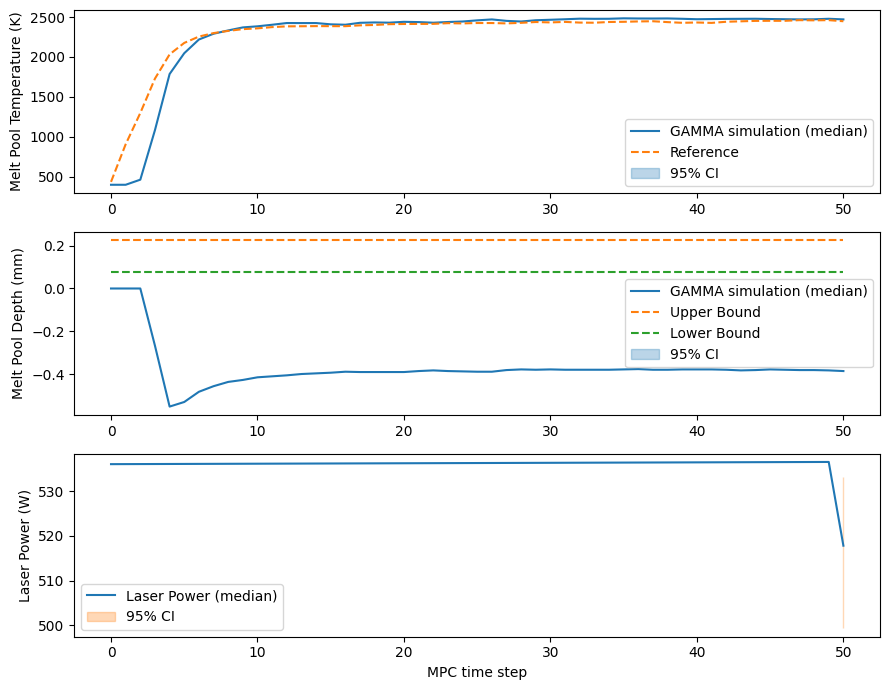

Laser 2:   1%|          | 50/6195 [00:35<1:13:08,  1.40it/s]

[CI DEBUG @ step 100] u_low=506.965271, u_mid=517.043945, u_high=530.320801, spread=2.335553e+01, std(norm)=5.773412e-02


Laser 2:   2%|▏         | 150/6195 [01:47<1:21:49,  1.23it/s]

[CI DEBUG @ step 200] u_low=527.020935, u_mid=539.857056, u_high=551.081726, spread=2.406079e+01, std(norm)=5.661503e-02


Laser 2:   4%|▍         | 250/6195 [03:00<1:20:12,  1.24it/s]

[CI DEBUG @ step 300] u_low=512.184692, u_mid=524.223816, u_high=537.402466, spread=2.521777e+01, std(norm)=6.034324e-02


Laser 2:   5%|▍         | 300/6195 [03:40<1:18:57,  1.24it/s]

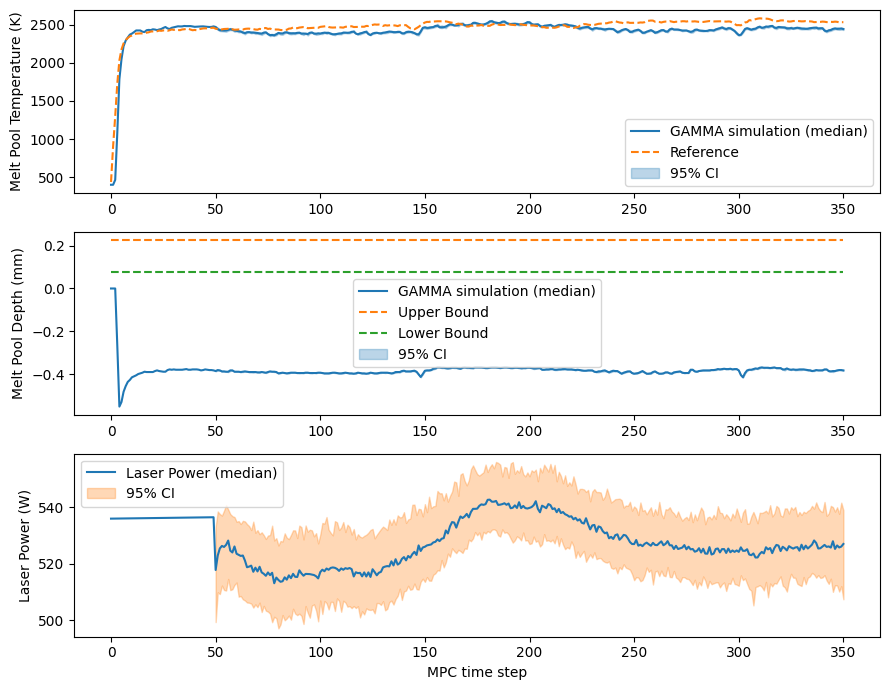

Laser 2:   6%|▌         | 350/6195 [04:21<1:21:27,  1.20it/s]

[CI DEBUG @ step 400] u_low=508.252869, u_mid=522.160706, u_high=535.837891, spread=2.758502e+01, std(norm)=6.547358e-02


Laser 2:   7%|▋         | 450/6195 [05:39<1:16:08,  1.26it/s]

[CI DEBUG @ step 500] u_low=532.417542, u_mid=542.202576, u_high=555.156494, spread=2.273895e+01, std(norm)=5.418562e-02


Laser 2:   9%|▉         | 550/6195 [06:59<1:17:50,  1.21it/s]

[CI DEBUG @ step 600] u_low=522.950989, u_mid=535.521667, u_high=547.625183, spread=2.467419e+01, std(norm)=5.262280e-02


Laser 2:  10%|▉         | 600/6195 [07:41<1:19:12,  1.18it/s]

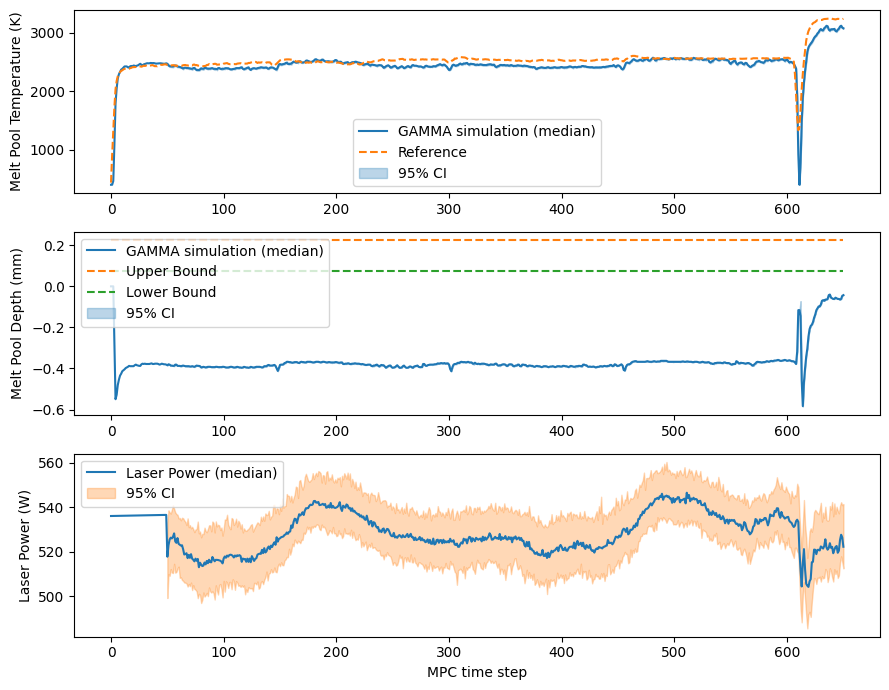

Laser 2:  10%|█         | 650/6195 [08:23<1:16:04,  1.21it/s]

[CI DEBUG @ step 700] u_low=522.863220, u_mid=531.646057, u_high=540.905762, spread=1.804254e+01, std(norm)=4.751911e-02


Laser 2:  12%|█▏        | 750/6195 [09:48<1:17:01,  1.18it/s]

[CI DEBUG @ step 800] u_low=522.845093, u_mid=531.455017, u_high=541.924500, spread=1.907941e+01, std(norm)=4.718057e-02


Laser 2:  13%|█▎        | 785/6195 [10:18<1:16:22,  1.18it/s]

In [ ]:
device = torch.device("cuda:0")

# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50
MC_SAMPLES = 100   # ⭐ MC Dropout 샘플 수

model_path = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/policy_model.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.1
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ⭐ Dropout만 활성화 (중요!)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.train()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/simulation_uncertainty"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number ───────────────────
for laser_num in range(2, 30):
    try:
        # ------------------------------------------------
        # Step 1: Load CSV
        # ------------------------------------------------
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # ------------------------------------------------
        # Step 2: GAMMA init
        # ------------------------------------------------
        GAMMA_class = GAMMA_obj(
            INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
            CLOUD_TARGET_BASE_PATH, solidus_temp, window,
            init_runs, sim_interval, laser_power_number=laser_num
        )

        # ------------------------------------------------
        # Step 3: Initial steps
        # ------------------------------------------------
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # ------------------------------------------------
        # Step 4: Inputs
        # ------------------------------------------------
        loc_Z  = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)

        fix_covariates = torch.tensor(
            np.concatenate((loc_Z, dist_X, dist_Y), axis=1),
            dtype=torch.float32
        ).to(device)

        laser_power_ref  = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = mp_temp_raw.copy()
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        mp_depth_raw = df["melt_pool_depth"].to_numpy()
        mp_depth = mp_depth_raw.copy()
        mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
        mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)

        # ------------------------------------------------
        # Step 5: GAMMA state init
        # ------------------------------------------------
        GAMMA_class.ref = mp_temp_ref.clone()
        GAMMA_class.fix_cov_all = fix_covariates.clone()
        GAMMA_class.x_past = init_avg.clone()
        GAMMA_class.u_past = laser_power_past.clone()

        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone()
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone()

        # ⭐ CI 저장 버퍼 초기화
        GAMMA_class.u_ci_save = torch.empty((0, 3), device=device)
        GAMMA_class.x_ci_save = torch.empty((0, 6), device=device)

        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1]
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1)

        # ------------------------------------------------
        # Step 6: Simulation loop
        # ------------------------------------------------
        N_step = len(mp_temp_ref) - P

        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            out = run_one_step_policy(
                GAMMA_class,
                model,
                P=P,
                window=window,
                mc_samples=MC_SAMPLES
            )

            # ⭐ CI 저장
            GAMMA_class.u_ci_save = torch.cat(
                (GAMMA_class.u_ci_save,
                 torch.tensor([[out["u_low"], out["u_mid"], out["u_high"]]], device=device)),
                dim=0
            )

            GAMMA_class.x_ci_save = torch.cat(
                (GAMMA_class.x_ci_save,
                 torch.tensor([[out["x_low"], out["x_mid"], out["x_high"],
                                out["d_low"], out["d_mid"], out["d_high"]]], device=device)),
                dim=0
            )

            if i % 300 == 0:
                plot_fig(GAMMA_class, N_step)

        # ------------------------------------------------
        # Step 7: Save outputs
        # ------------------------------------------------
        pd.DataFrame(GAMMA_class.x_past_save.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.u_past_save.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.ref.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.u_ci_save.cpu().numpy(),
                     columns=["u_low", "u_mid", "u_high"]).to_csv(
            os.path.join(save_dir, f"u_ci_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.x_ci_save.cpu().numpy(),
                     columns=[
                         "temp_low", "temp_mid", "temp_high",
                         "depth_low", "depth_mid", "depth_high"
                     ]).to_csv(
            os.path.join(save_dir, f"x_ci_laser_{laser_num}.csv"), index=False)

        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")
